<style>
.jp-RenderedMarkdown, .rendered_html { font-family: Arial, Helvetica, sans-serif; font-size: 15px; line-height: 1.55; }
.jp-RenderedMarkdown h1, .rendered_html h1 { font-size: 24px; font-weight: 700; }
.jp-RenderedMarkdown h2, .rendered_html h2 { font-size: 20px; font-weight: 650; }
.jp-RenderedMarkdown h3, .rendered_html h3 { font-size: 17px; font-weight: 600; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li, .rendered_html p, .rendered_html li { font-size: 15px; }
.jp-RenderedMarkdown code, .rendered_html code { font-size: 13px; }
</style>


# MeridianAI — Advanced Customer Segmentation

# Notebook 04 – Advanced Customer Intelligence Engineering

## Objective

The objective of this notebook is to extend the customer segmentation process by applying advanced machine learning techniques and engineering business-oriented customer intelligence features.

This notebook includes:

- Feature Scaling using StandardScaler
- Density-Based Clustering (DBSCAN)
- Hierarchical Clustering (Agglomerative Clustering)
- Customer Anomaly Detection using Isolation Forest
- Customer Intelligence Score Generation
- Customer Tier Classification
- Customer Persona Generation

These engineered customer attributes provide valuable business insights and improve the performance of downstream machine learning tasks such as churn prediction, recommendation systems, sales forecasting, and explainable AI.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from sklearn.ensemble import IsolationForest

Load Segmented Dataset

In [2]:
customer_df = pd.read_csv(
    "../data/processed/customer_segments.csv"
)

In [3]:
customer_df.head()

,CustomerID,TotalTransactions,TotalQuantity,TotalSpent,LastPurchaseDate,Recency,Frequency,Monetary,Cluster,Persona
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00,325,12,77556.46,1,Churn Risk Customers
1,12347.0,8,2967,4921.53,2011-12-07 15:52:00,1,8,4921.53,4,New Customers
2,12348.0,5,2714,2019.40,2011-09-25 13:13:00,74,5,2019.40,4,New Customers
3,12349.0,4,1624,4428.69,2011-11-21 09:51:00,18,4,4428.69,4,New Customers
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309,1,334.40,0,VIP Customers


In [4]:
X = customer_df[
    ['Recency', 'Frequency', 'Monetary']
]

# Feature Scaling

Before applying clustering and anomaly detection algorithms, numerical features are standardized using StandardScaler.

Algorithms such as DBSCAN, Agglomerative Clustering, and Isolation Forest are sensitive to differences in feature scales. Standardization ensures that every feature contributes equally during distance calculations and anomaly detection.

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Density-Based Customer Segmentation (DBSCAN)

DBSCAN groups customers based on regions of high density while identifying isolated customers as noise.

Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand and can discover irregularly shaped customer groups.

In [6]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

customer_df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [7]:
customer_df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    5815
-1      63
Name: count, dtype: int64

Visualizing DBSCAN

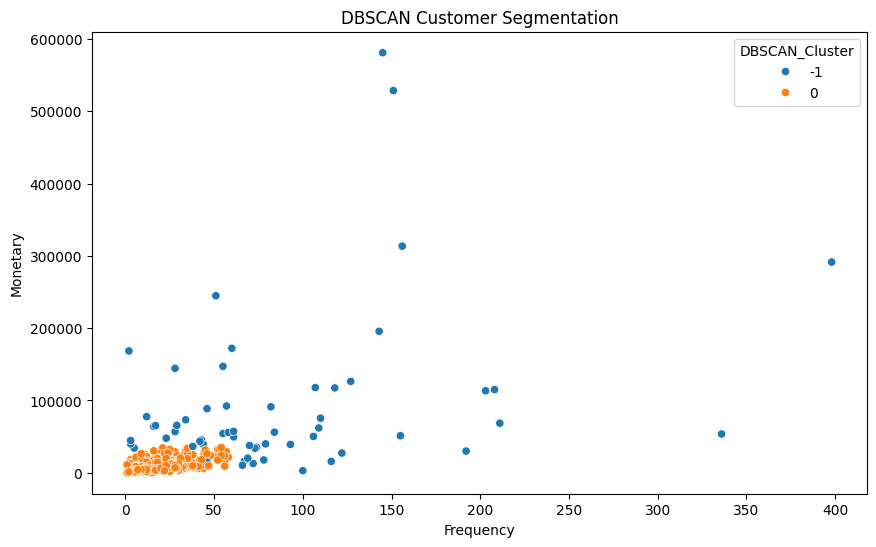

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=customer_df['Frequency'],
    y=customer_df['Monetary'],
    hue=customer_df['DBSCAN_Cluster'],
    palette='tab10'
)

plt.title("DBSCAN Customer Segmentation")

plt.show()

# Hierarchical Customer Segmentation

Agglomerative Clustering builds a hierarchy of customer groups by repeatedly merging the closest clusters.

This approach provides another perspective on customer similarity and helps validate the segmentation produced by K-Means and DBSCAN.

In [9]:
hierarchical = AgglomerativeClustering(
    n_clusters=5
)

customer_df['Hierarchical_Cluster'] = (
    hierarchical.fit_predict(X_scaled)
)

VISUALIZE HEIRARCHICAL CLUSTERS

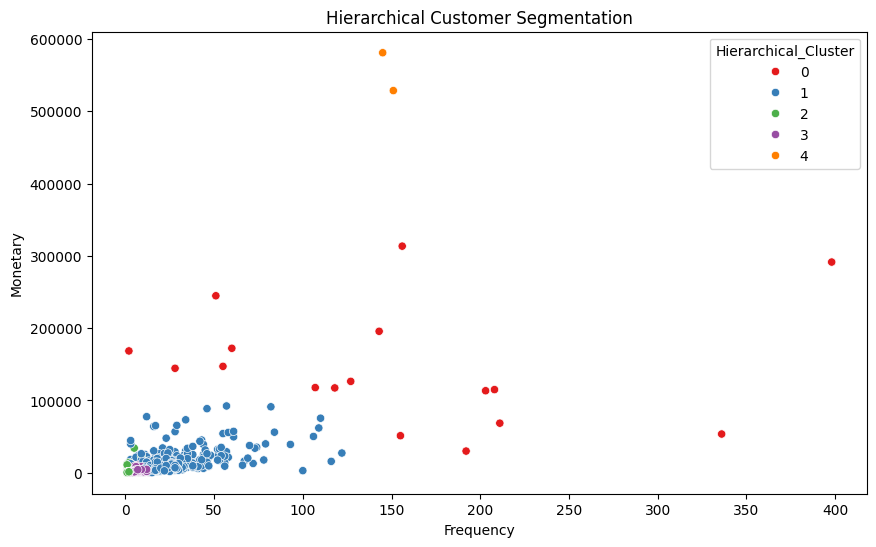

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=customer_df['Frequency'],
    y=customer_df['Monetary'],
    hue=customer_df['Hierarchical_Cluster'],
    palette='Set1'
)

plt.title("Hierarchical Customer Segmentation")

plt.show()

K-MEANS SCORE

In [11]:
kmeans_score = silhouette_score(
    X_scaled,
    customer_df['Cluster']
)

print("KMeans Score:", kmeans_score)

KMeans Score: 0.6005893012935021


HEIRARCHICAL SCORE

In [12]:
hierarchical_score = silhouette_score(
    X_scaled,
    customer_df['Hierarchical_Cluster']
)

print("Hierarchical Score:", hierarchical_score)

Hierarchical Score: 0.5494808790736038


Customer Intelligence Scoring

A composite Customer Intelligence Score (CIS) was developed by combining six business indicators: Total Spending, Monetary Value, Purchase Frequency, Total Transactions, Quantity Purchased, and Recency. Each feature was normalized using Min-Max Scaling before assigning business-driven weights based on its contribution to customer value.

Customers were then segmented into Bronze, Silver, Gold, and Platinum tiers using percentile-based thresholds instead of equal-sized bins. This approach better reflects real-world retail behaviour, where a relatively small percentage of customers contribute disproportionately to revenue, making the segmentation more realistic and actionable.

In [13]:
from sklearn.preprocessing import MinMaxScaler

score_features = [
    "TotalSpent",
    "Monetary",
    "Frequency",
    "TotalTransactions",
    "TotalQuantity",
    "Recency"
]

score_scaler = MinMaxScaler()

customer_df[score_features] = score_scaler.fit_transform(
    customer_df[score_features]
)

customer_df["CustomerScore"] = (

      customer_df["TotalSpent"] * 0.30

    + customer_df["Monetary"] * 0.25

    + customer_df["Frequency"] * 0.20

    + customer_df["TotalTransactions"] * 0.15

    + customer_df["TotalQuantity"] * 0.05

    + (1-customer_df["Recency"]) * 0.05

)

In [14]:
customer_df["CustomerScore"] = (

    customer_df["CustomerScore"]
    - customer_df["CustomerScore"].min()

) / (

    customer_df["CustomerScore"].max()
    - customer_df["CustomerScore"].min()

)

# Customer Personas

Customer personas translate numerical customer behaviour into business-friendly labels.

Examples include:

- VIP Customer
- Loyal Customer
- Regular Customer
- At-Risk Customer

These personas improve interpretability for non-technical business users.

In [15]:
bronze_cutoff = customer_df["CustomerScore"].quantile(0.40)
silver_cutoff = customer_df["CustomerScore"].quantile(0.70)
gold_cutoff = customer_df["CustomerScore"].quantile(0.90)

conditions = [

    customer_df["CustomerScore"] >= gold_cutoff,

    (customer_df["CustomerScore"] >= silver_cutoff) &
    (customer_df["CustomerScore"] < gold_cutoff),

    (customer_df["CustomerScore"] >= bronze_cutoff) &
    (customer_df["CustomerScore"] < silver_cutoff),

    customer_df["CustomerScore"] < bronze_cutoff

]

labels = [

    "Platinum",
    "Gold",
    "Silver",
    "Bronze"

]

customer_df["Tier"] = np.select(
    conditions,
    labels,
    default="Bronze"
)

In [16]:
customer_df["Tier"].value_counts()

Tier
Bronze      2351
Silver      1763
Gold        1176
Platinum     588
Name: count, dtype: int64

# Customer Tier Distribution

Customers are categorized into Bronze, Silver, Gold, and Platinum tiers based on their Customer Intelligence Score.

These tiers simplify customer value assessment and support personalized marketing, loyalty programs, and business decision-making.

C:\Users\Garvit\AppData\Local\Temp\ipykernel_17136\787019326.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


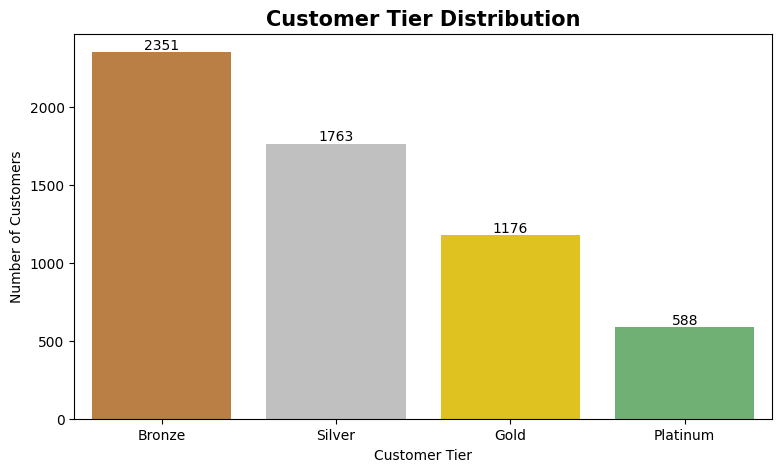

In [17]:
plt.figure(figsize=(9,5))

order = ["Bronze","Silver","Gold","Platinum"]

ax = sns.countplot(
    data=customer_df,
    x="Tier",
    order=order,
    palette=[
        "#CD7F32",
        "#C0C0C0",
        "#FFD700",
        "#66BB6A"
    ]
)

plt.title(
    "Customer Tier Distribution",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Customer Tier")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [18]:
customer_df["CustomerScore"].describe()

count    5878.000000
mean        0.058544
std         0.039885
min         0.000000
25%         0.035253
50%         0.062053
75%         0.071804
max         1.000000
Name: CustomerScore, dtype: float64

# Customer Value Matrix

The Customer Value Matrix provides a business-oriented visualization of customer behaviour by comparing purchase frequency and monetary value.

Each point represents an individual customer.

- X-axis → Purchase Frequency
- Y-axis → Monetary Value
- Colour → Customer Tier
- Bubble Size → Total Spending

This visualization enables business stakeholders to quickly identify high-value loyal customers, regular shoppers, occasional buyers, and low-value customers for targeted marketing strategies.

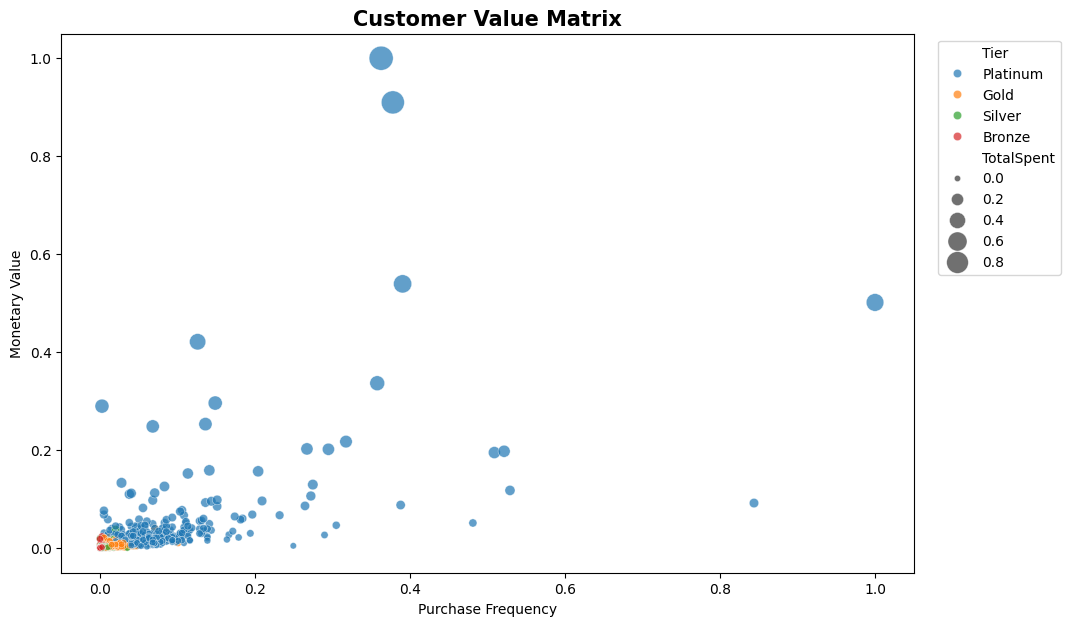

In [19]:
plt.figure(figsize=(11,7))

sns.scatterplot(
    data=customer_df,
    x="Frequency",
    y="Monetary",
    hue="Tier",
    size="TotalSpent",
    sizes=(20,300),
    alpha=0.7
)

plt.title(
    "Customer Value Matrix",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.show()

# Customer Intelligence Score Distribution

The histogram illustrates the distribution of the calculated Customer Intelligence Score across the customer base.

The score combines multiple business metrics into a single value representing overall customer worth.

Higher scores indicate customers with stronger purchasing behaviour and greater long-term business value.

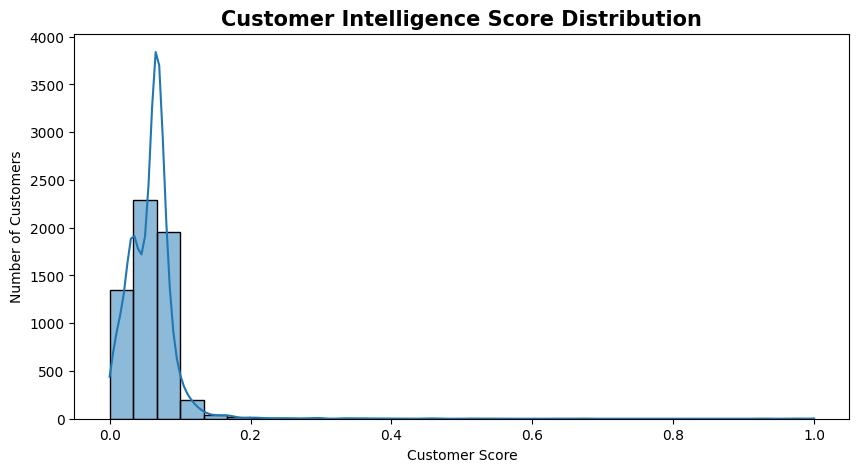

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_df["CustomerScore"],
    bins=30,
    kde=True
)

plt.title(
    "Customer Intelligence Score Distribution",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Customer Score")
plt.ylabel("Number of Customers")

plt.show()

# Revenue Contribution by Customer Tier

This visualization demonstrates how different customer tiers contribute to overall business revenue.

Although Platinum customers represent a relatively small percentage of the customer base, they are expected to contribute a disproportionately large share of revenue.

The analysis supports targeted retention strategies for high-value customers.

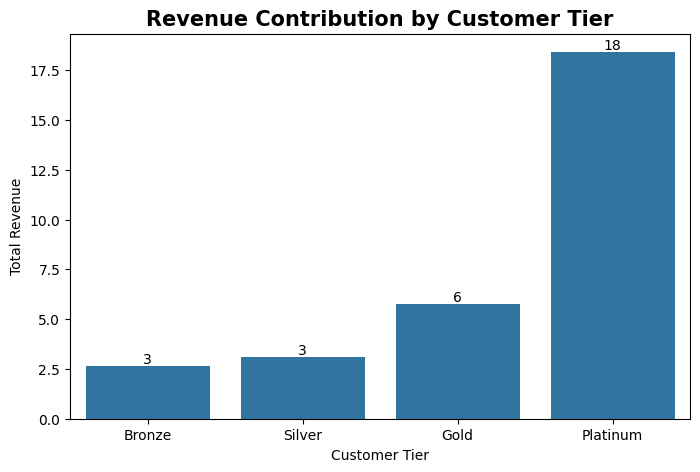

In [21]:
tier_sales = (
    customer_df
    .groupby("Tier")["TotalSpent"]
    .sum()
    .reindex(["Bronze","Silver","Gold","Platinum"])
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=tier_sales.index,
    y=tier_sales.values
)

plt.title(
    "Revenue Contribution by Customer Tier",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Customer Tier")
plt.ylabel("Total Revenue")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

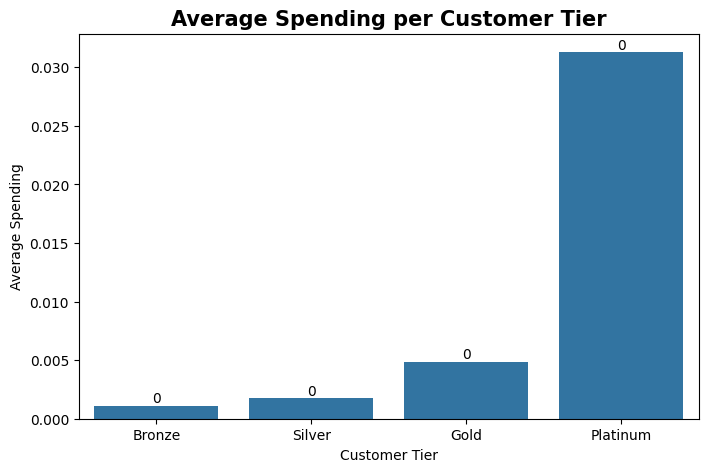

In [22]:
avg_spending = (
    customer_df
    .groupby("Tier")["TotalSpent"]
    .mean()
    .reindex(["Bronze","Silver","Gold","Platinum"])
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=avg_spending.index,
    y=avg_spending.values
)

plt.title(
    "Average Spending per Customer Tier",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Customer Tier")
plt.ylabel("Average Spending")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

# Customer Anomaly Detection using Isolation Forest

Isolation Forest is used to identify customers whose purchasing behaviour differs significantly from the majority. These customers may represent exceptionally valuable customers, dormant customers, or unusual purchasing patterns that require further business investigation.

In [25]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalSpent",
    "TotalTransactions",
    "TotalQuantity"
]

iso_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

customer_df["Anomaly"] = iso_model.fit_predict(
    customer_df[features]
)

customer_df["Anomaly"] = customer_df["Anomaly"].replace({
    1: "Normal",
    -1: "Anomaly"
})

customer_df["Anomaly"].value_counts()

Anomaly
Normal     5760
Anomaly     118
Name: count, dtype: int64

In [29]:
##Business Summary

print("="*45)
print("CUSTOMER BUSINESS SUMMARY")
print("="*45)

print(f"Total Customers        : {len(customer_df)}")
print(f"Average Customer Score : {customer_df['CustomerScore'].mean():.3f}")
print(f"Highest Customer Score : {customer_df['CustomerScore'].max():.3f}")
print(f"Lowest Customer Score  : {customer_df['CustomerScore'].min():.3f}")

print("\nCustomer Tier Distribution")
print(customer_df["Tier"].value_counts())

print("\nAverage Revenue by Tier")
print(customer_df.groupby("Tier")["TotalSpent"].mean())

print("\nDetected Anomalies")
print(customer_df["Anomaly"].value_counts())

CUSTOMER BUSINESS SUMMARY
Total Customers        : 5878
Average Customer Score : 0.059
Highest Customer Score : 1.000
Lowest Customer Score  : 0.000

Customer Tier Distribution
Tier
Bronze      2351
Silver      1763
Gold        1176
Platinum     588
Name: count, dtype: int64

Average Revenue by Tier
Tier
Bronze      0.001122
Gold        0.004880
Platinum    0.031303
Silver      0.001754
Name: TotalSpent, dtype: float64

Detected Anomalies
Anomaly
Normal     5760
Anomaly     118
Name: count, dtype: int64


In [26]:
customer_df.to_csv(
    "../data/processed/advanced_customer_segments.csv",
    index=False
)

# Business Conclusion

Advanced customer intelligence features were successfully engineered using multiple unsupervised machine learning techniques.

Key outcomes include:

- StandardScaler normalized customer features prior to machine learning.
- DBSCAN identified density-based customer groups without requiring a predefined number of clusters.
- Agglomerative Clustering provided hierarchical customer segmentation for comparison and validation.
- Isolation Forest detected anomalous customers with unusual purchasing behaviour, enabling potential fraud detection and customer risk analysis.
- A Customer Intelligence Score was generated to summarize overall customer value.
- Customers were categorized into meaningful business tiers (Bronze, Silver, Gold, and Platinum) using business-oriented score thresholds.
- Business-friendly customer personas were created to improve interpretability for marketing and management teams.

The engineered customer dataset generated in this notebook serves as the primary input for customer churn prediction, recommendation systems, sales forecasting, and explainable AI in the remaining stages of the MeridianAI project.